In [58]:
# Lets import the required libraries and packages
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn import metrics
from sklearn.metrics import precision_recall_curve, roc_auc_score
from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, f1_score
# Plot Style
from matplotlib import style
sns.set_context("paper")
style.use('fivethirtyeight')
sns.set_theme()

In [59]:
# Lets Supress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

In [60]:
# Lets import and read the dataset
fraud_train = pd.read_csv("fraudTest.csv")
fraud_train

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,555714,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,Michael,Olson,M,558 Michael Estates,...,40.4931,-91.8912,519,Town planner,1966-02-13,9b1f753c79894c9f4b71f04581835ada,1388534347,39.946837,-91.333331,0
555715,555715,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,Jose,Vasquez,M,572 Davis Mountains,...,29.0393,-95.4401,28739,Futures trader,1999-12-27,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661049,-96.186633,0
555716,555716,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,Ann,Lawson,F,144 Evans Islands Apt. 683,...,46.1966,-118.9017,3684,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658340,-119.715054,0
555717,555717,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,Eric,Preston,M,7020 Doyle Stream Apt. 951,...,44.6255,-116.4493,129,Cartographer,1965-12-15,14392d723bb7737606b2700ac791b7aa,1388534364,44.470525,-117.080888,0


In [61]:
# Lets convert the columns to appropriate formats
fraud_train['trans_date_trans_time']= pd.to_datetime(fraud_train['trans_date_trans_time'])

In [62]:
fraud_train['dob'] = pd.to_datetime(fraud_train['dob'], errors='coerce')

In [63]:
fraud_train['trans_Date']=fraud_train.trans_date_trans_time.dt.date
fraud_train['trans_Time']=fraud_train.trans_date_trans_time.dt.time
fraud_train.trans_Date = pd.to_datetime(fraud_train['trans_Date'],format='%Y-%m-%d')

In [64]:
fraud_train['job'][fraud_train['job'].str.contains('(Teacher|teacher|Lecturer|lecturer|Professor|professor)',regex=True)].value_counts()

job
Early years teacher                       2475
Secondary school teacher                  2447
Special educational needs teacher         2184
Teacher, special educational needs        1984
Further education lecturer                1734
English as a second language teacher      1712
Private music teacher                     1558
Lecturer, further education               1544
Lecturer, higher education                1410
Teacher, early years/pre                  1175
Teacher, secondary school                 1106
Teacher, primary school                    723
Teacher, English as a foreign language     460
English as a foreign language teacher      241
TEFL teacher                               227
Professor Emeritus                         224
Primary school teacher                     224
Teacher, adult education                   223
Associate Professor                        204
Name: count, dtype: int64

In [65]:
fraud_train['job'].replace(["Secondary school teacher","Early years teacher","TEFL teacher",
        "Special educational needs teacher","Teacher, special educational needs",
        "Further education lecturer","English as a second language teacher","Associate Professor",
        "Lecturer, further education","Private music teacher","Lecturer, higher education",
        "Teacher, early years/pre","Teacher, secondary school","Teacher, primary school",
        "Teacher, English as a foreign language","Primary school teacher","Professor Emeritus",
        "English as a foreign language teacher","Teacher, adult education"],'Teacher', inplace=True)

In [66]:
fraud_train['job'][fraud_train['job'].str.contains('(Engineering|engineering|Engineer|engineer)',
                                                        regex=True)].value_counts()

job
Materials engineer                       3441
Mining engineer                          2611
Water engineer                           2576
Mechanical engineer                      2430
Engineer, automotive                     2416
Petroleum engineer                       2379
Energy engineer                          2370
Chemical engineer                        2248
Engineer, biomedical                     2210
Drilling engineer                        2189
Electrical engineer                      2122
Engineer, control and instrumentation    1993
Engineer, production                     1952
Engineering geologist                    1769
Structural engineer                      1558
Engineer, mining                         1517
Engineer, electronics                    1495
Engineer, land                           1358
Manufacturing engineer                   1320
Site engineer                            1301
Electronics engineer                     1293
Geologist, engineering        

In [67]:
fraud_train['job'].replace(["Materials engineer","Mining engineer","Water engineer","Engineer, land",
        "Mechanical engineer","Engineer, automotive","Petroleum engineer","Energy engineer",
        "Chemical engineer","Engineer, biomedical","Drilling engineer","Electrical engineer",
        "Engineer, production","Engineer, control and instrumentation","Engineering geologist",
        "Structural engineer","Engineer, mining","Engineer, electronics","Site engineer",
        "Geologist, engineering","Electronics engineer","Manufacturing engineer","Engineer, site",
        "Maintenance engineer","Engineer, petroleum","Communications engineer","Network engineer",
        "Civil engineer, contracting","Engineer, technical sales","Biomedical engineer",
        "Engineer, drilling","Aeronautical engineer","Production engineer","Engineer, maintenance",
        "Engineer, agricultural","Engineer, civil (contracting)","Engineer, communications",
        "Building services engineer","Control and instrumentation engineer","Engineer, structural",
        "Engineer, building services","Manufacturing systems engineer","Engineer, aeronautical",
        "Engineer, broadcasting (operations)","Engineer, manufacturing","Broadcast engineer",
        "Engineer, civil (consulting)","Engineer, materials","Software engineer","Engineer, water",
        'Contracting civil engineer'], 'Engineer', inplace=True)

In [68]:
fraud_train['job'][fraud_train['job'].str.contains('(Scientist|scientist)',
                                                                        regex=True)].value_counts()

job
Scientist, audiological                                        3060
Audiological scientist                                         2683
Scientist, research (maths)                                    2609
Geoscientist                                                   2421
Scientist, marine                                              2217
Research scientist (physical sciences)                         2134
Scientist, biomedical                                          1732
Product/process development scientist                          1344
Biomedical scientist                                           1304
Soil scientist                                                 1090
Research scientist (life sciences)                              893
Scientist, research (physical sciences)                         871
Scientist, physiological                                        839
Physiological scientist                                         654
Research scientist (maths)                  

In [69]:
fraud_train['job'].replace(["Scientist, audiological","Audiological scientist","Data scientist",
            "Scientist, research (maths)","Geoscientist","Research scientist (physical sciences)",
            "Scientist, marine","Scientist, biomedical","Biomedical scientist",
            "Product/process development scientist","Soil scientist","Scientist, physiological",
            "Research scientist (life sciences)","Scientist, research (physical sciences)",
            "Physiological scientist","Research scientist (maths)","Research scientist (medical)",
            "Scientist, research (medical)","Water quality scientist",
            "Scientist, clinical (histocompatibility and immunogenetics)"],'Scientist', inplace=True)

In [70]:
fraud_train['job'].replace(['Chief Executive Officer','Armed forces technical officer',
            'Personnel officer','Information officer','Local government officer',"Police officer",
            'Public relations officer','Education officer, community',"Tourism officer",
            'Field trials officer','Charity officer','Nature conservation officer',
            'Environmental education officer',"Environmental education officer",
            "Museum education officer","Medical technical officer","Chief Operating Officer",
           'Race relations officer','Prison officer','Chief Strategy Officer',"Immigration officer", 
            'Probation officer','Exhibitions officer, museum/gallery','Fisheries officer',     
            'Research officer, trade union ','Research officer, political party',   
            "Historic buildings inspector/conservation officer","Trading standards officer",
            "Careers information officer","Regulatory affairs officer","Human resources officer",
            "Armed forces training and education officer","Chief Technology Officer",
            "Chief Financial Officer","Equality and diversity officer","Waste management officer",
            "Chief Marketing Officer","Museum/gallery exhibitions officer",
            "Sports development officer","Arts development officer","Community education officer",
     "Emergency planning/management officer","Armed forces logistics/support/administrative officer",
           "Conservation officer, historic buildings","Training and development officer",
            "Social research officer, government",'Education officer, museum'],
                          'Officer', inplace=True)

In [71]:
fraud_train['job'].replace(["Surveyor, land/geomatics","Building surveyor","Quantity surveyor",
            "Land/geomatics surveyor","Surveyor, minerals","Insurance risk surveyor",
            "Commercial/residential surveyor","Building control surveyor","Surveyor, rural practice",
            "Planning and development surveyor","Surveyor, mining","Rural practice surveyor",
            "Hydrographic surveyor","Minerals surveyor","Surveyor, hydrographic"],
                          'Surveyor', inplace=True)

In [72]:
fraud_train['job'].replace(["Exhibition designer","Designer, ceramics/pottery","Ceramics designer",
            "Designer, industrial/product","Designer, jewellery","Designer, exhibition/display",
            "Designer, furniture","Web designer","Product designer","Glass blower/designer",
            "Furniture designer","Industrial/product designer","Set designer","Designer, textile",
            "Designer, interior/spatial","Jewellery designer","Designer, multimedia",
            "Designer, television/film set","Interior and spatial designer","Textile designer"],
                          'Designer', inplace=True)

In [73]:
fraud_train['job'].replace(["Facilities manager","Travel agency manager","Call centre manager",
            "Heritage manager","Production manager","Energy manager","Television floor manager",
            "Leisure centre manager","Tourist information centre manager","Farm manager",
            "Fitness centre manager","Health service manager","Information systems manager",
            "Theme park manager","Pension scheme manager","Public house manager","Quarry manager",
            "Records manager","Logistics and distribution manager","Location manager",
            "Theatre manager","Retail manager","Art gallery manager","Stage manager","Tour manager",
            "Outdoor activities/education manager","Product manager","Hotel manager",
            "Restaurant manager, fast food","Purchasing manager","Catering manager",
            "Environmental manager","Estate manager/land agent","Forest/woodland manager",
                           "Warehouse manager"],'Manager', inplace=True)

In [74]:
fraud_train['job'].replace(["Psychologist, forensic","Counselling psychologist",
            "Educational psychologist","Occupational psychologist","Forensic psychologist",
            "Psychologist, counselling","Sport and exercise psychologist",
            "Psychologist, sport and exercise","Psychologist, clinical","Clinical psychologist"],
                          'Psychologist', inplace=True)

In [75]:
fraud_train['job'].replace(["Film/video editor","Magazine features editor","Editor, commissioning",
                    "Video editor","Editor, film/video","Editor, magazine features",
                    "Commissioning editor"],'Editor', inplace=True)

In [76]:
fraud_train['job'].replace(['Radio producer','Television/film/video producer',
                'Producer, television/film/video','Producer, radio'],'Producer', inplace=True)

In [77]:
fraud_train['job'].replace(["Psychotherapist, child","Therapist, occupational","Physiotherapist",
                "Child psychotherapist","Phytotherapist","Therapist, horticultural","Therapist, art",
                "Therapist, sports","Music therapist","Horticultural therapist","Art therapist",
                "Nutritional therapist","Dance movement psychotherapist","Psychotherapist",
                "Therapist, drama","Therapist, music","Occupational therapist"],
                          'Therapist', inplace=True)

In [78]:
fraud_train['job'].replace(["Learning disability nurse","Nurse, children's","Paediatric nurse",
                    "Mental health nurse","Psychiatric nurse","Nurse, mental health"],
                          'Nurse', inplace=True)

In [79]:
fraud_train['job'].replace(["Television production assistant","Radio broadcast assistant",
                    "Politician's assistant","Production assistant, radio",
                    "Production assistant, television"], 'Assistant', inplace=True)

In [80]:
fraud_train['job'].replace(["Public relations account executive","Advertising account executive",
                    "Sales executive","Chartered legal executive (England and Wales)",
                    "Marketing executive","Sales promotion account executive"],
                          'Executive', inplace=True)

In [81]:
fraud_train['job'].replace(["Librarian, public","Librarian, academic","Public librarian",
                           "Academic librarian"], 'Librarian', inplace=True)

In [82]:
fraud_train['job'].replace(["Social researcher","Programme researcher, broadcasting/film/video",
                    "Market researcher","Operational researcher","Telecommunications researcher"],
                          'Researcher', inplace=True)

In [83]:
fraud_train['job'].replace(["Environmental consultant","Agricultural consultant","IT consultant",
                    "Pensions consultant","Public affairs consultant","Management consultant",
                    "Horticultural consultant"], 'Consultant', inplace=True)

In [84]:
fraud_train['job'].replace(["Museum/gallery conservator","Furniture conservator/restorer",
                "Conservator, museum/gallery","Conservator, furniture"], 'Conservator', inplace=True)

In [85]:
fraud_train['job'].replace(["Investment banker, corporate","Corporate investment banker",
                "Retail banker","Investment banker, operational","Operational investment banker"], 
                'Banker', inplace=True)

In [86]:
fraud_train['job'].replace(["Geochemist","Clinical biochemist","Biochemist, clinical",
                    "Chemist, analytical","Analytical chemist"], 'Chemist', inplace=True)

In [87]:
fraud_train['job'].replace(["Chartered public finance accountant","Chartered accountant",
                    "Accountant, chartered public finance","Accountant, chartered certified",
                    "Accountant, chartered"], 'Chartered Accountant', inplace=True)

In [88]:
fraud_train['job'].replace(["Administrator","Administrator, local government",
                "Administrator, education","Administrator, charities/voluntary organisations",
                "Database administrator","Secretary/administrator","Sports administrator",
                "Education administrator","Civil Service administrator","Administrator, arts"], 
                          'Administrator', inplace=True)

In [89]:
fraud_train['job'].replace(["Copywriter, advertising","Science writer","Insurance underwriter",
                    "Advertising copywriter","Writer"], 'Writer', inplace=True)

In [90]:
fraud_train['job'].replace(["Surgeon","Hospital doctor","Doctor, general practice","Doctor, hospital",
                "Tree surgeon","Neurosurgeon","Veterinary surgeon","General practice doctor"], 
                          'Doctor', inplace=True)

In [91]:
fraud_train['job'].replace(["Buyer, industrial","Media buyer","Retail buyer","Buyer, retail","Industrial buyer"], 
                                                                                  'Buyer', inplace=True)

In [92]:
fraud_train['job'].replace(["Cytogeneticist","Plant breeder/geneticist","Geneticist, molecular",
                        "Clinical cytogeneticist"], 'Geneticist', inplace=True)

In [93]:
fraud_train['job'].replace(["Pharmacist, community","Community pharmacist","Pharmacist, hospital",
                           "Hospital pharmacist"], 'Pharmacist', inplace=True)

In [94]:
fraud_train['job'].replace(["Physicist, medical","Health physicist","Medical physicist",
                           "Geophysicist/field seismologist"], 'Physicist', inplace=True)

In [95]:
fraud_train['job'].replace(["Systems analyst","Risk analyst","Investment analyst","Intelligence analyst"], 
                                                                          'Analyst', inplace=True)

In [96]:
fraud_train['job'].replace(["Clothing/textile technologist","Colour technologist","Animal technologist",
                "Garment/textile technologist","Architectural technologist"], 'Technologist', inplace=True)

In [97]:
fraud_train['job'].replace(["Accounting technician","Scientific laboratory technician",
                           "Teaching laboratory technician"], 'Technician', inplace=True)

In [98]:
fraud_train['job'].replace(['Amenity horticulturist','Commercial horticulturist','Horticulturist, commercial'], 
                                                                      'Horticulturist', inplace=True)

fraud_train['job'].replace(['Retail merchandiser','Merchandiser, retail','Visual merchandiser'], 
                                                                      'Merchandiser', inplace=True)

fraud_train['job'].replace(['Cabin crew','Air cabin crew'],'Cabin crew', inplace=True)

In [99]:
def label_states (row):
    if row['state'] in ['CT','ME','MA','NH','NJ','NY','PA','RI','VT']:
        return 'Northeast'
    if row['state'] in ['IL','IN','IA','KS','MI','MN','MO','NE','ND','OH','SD','WI']:
        return 'Midwest'
    if row['state'] in ['AL','AR','DE','DC','FL','GA','KY','LA','MD','MS','NC','OK','SC','TN','Tx','VA','WV']:
        return 'South'
    else:
        return 'West'

In [100]:
fraud_train['state_bin'] = fraud_train.apply(lambda row: label_states(row), axis=1)

In [101]:

fraud_train["age"] = fraud_train["dob"].apply(lambda x: (pd.to_datetime('now').year - x.year))


In [102]:
bin_manual = [0, 20, 30, 40, 50, 60, 70, 80, 90, 100]
labs = ['0-20', '20-30', '30-40', '40-50','50-60','60-70','70-80', '80-90','90-100']
fraud_train['age_bin'] = pd.cut(fraud_train.age, bins=bin_manual, labels=labs)

In [103]:
fraud_train['trans_Year']=fraud_train.trans_Date.dt.year
fraud_train['trans_year_month'] = fraud_train.trans_Date.dt.to_period('M')
fraud_train['trans_Month']=fraud_train.trans_Date.dt.month
fraud_train['trans_Hour']=fraud_train.trans_date_trans_time.dt.hour
fraud_train['trans_Day']=fraud_train.trans_Date.dt.day
fraud_train['trans_weekday'] = fraud_train.trans_Date.dt.day_name()




In [104]:
from math import radians, cos, sin, asin, sqrt 

def haversine_distance(lat, long, merch_lat, merch_long): 
      
    # The math module contains a function named 
    # radians which converts from degrees to radians. 
    long = np.radians(long) 
    merch_long = np.radians(merch_long) 
    lat = np.radians(lat) 
    merch_lat = np.radians(merch_lat) 
       
    # Haversine formula  
    dlon = merch_long - long  
    dlat = merch_lat - lat
    a = np.sin(dlat / 2)**2 + np.cos(lat) * np.cos(merch_lat) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a)) 
    #c = 2 * np.arctan2(a**0.5, (1-a)**0.5)
    
    # Radius of earth in kilometers.  
    r = 6371
    d=  c * r
    # calculate the result 
    return round(d,2)

In [105]:
fraud_train['dist']=fraud_train[['lat', 'long', 'merch_lat', 'merch_long']].apply(
                                        lambda x:haversine_distance(x[0], x[1], x[2], x[3]), axis=1)

In [106]:
grp_by_cc=fraud_train.groupby(['cc_num'])

In [107]:
# Get previous longitude/latitude and time elapsed of a transaction
fraud_train['prev_merch_lat']=grp_by_cc['merch_lat'].transform(lambda x:x.shift(1)).fillna(
                                                                        fraud_train['merch_lat'])
fraud_train['prev_merch_long']=grp_by_cc['merch_long'].transform(lambda x:x.shift(1)).fillna(
                                                                        fraud_train['merch_long'])
# Time since previous transaction in hours
fraud_train['time_since_prev_transaction'] = grp_by_cc['trans_Hour'].transform(lambda x:round(
                                                                     (x-x.shift(1)),1)).fillna(0)

In [108]:
fraud_train['distance_between_merchants']=fraud_train.apply(lambda x:haversine_distance(
                                            x.prev_merch_lat,x.prev_merch_long,x.merch_lat,x.merch_long), axis=1)

In [109]:
fraud_train= fraud_train.drop(['prev_merch_lat','prev_merch_long','merch_lat','merch_long','zip'],axis=1)
fraud_train= fraud_train.drop(['age_bin','trans_Date','unix_time', 'trans_Day','trans_year_month'],axis=1)
fraud_train= fraud_train.drop(['trans_Time','trans_date_trans_time','dob', 'state_bin'],axis=1)



In [110]:
#############ADDED ON 5 AUGUST#############
# Lets delete unwanted column
fraud_train= fraud_train.drop(['Unnamed: 0'],axis=1)
fraud_train= fraud_train.drop(['first'],axis=1)
fraud_train= fraud_train.drop(['last'],axis=1)


In [111]:
from sklearn.preprocessing import LabelEncoder
def preprocess_data(X):
# Convert categorical columns if any
    label_encoders = {}
    for col in X.columns:
        if X[col].dtype == 'object':
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col])
            label_encoders[col] = le
    
    return X, label_encoders

# Preprocess the data
X_train_preprocessed, label_encoders = preprocess_data(fraud_train)

In [112]:
from sklearn.model_selection import train_test_split

# Putting feature variable to X
X = X_train_preprocessed.drop(['is_fraud','cc_num', 'trans_num'],axis=1)

# Putting response variable to y
y = X_train_preprocessed['is_fraud']

## Load model and prediction on test data 

In [113]:
import joblib
# Load the model using joblib
loaded_model = joblib.load("xgboost_best.joblib")
# Use the loaded model to make predictions or evaluate further


ROC AUC Score: 0.9810813824736082


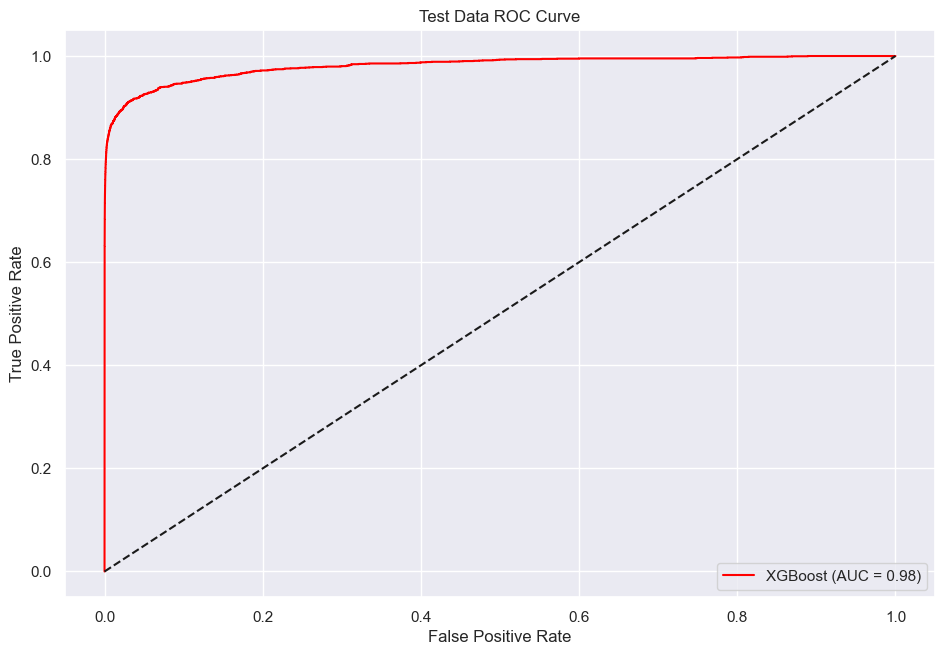

Optimized XGBoost Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.73      0.77      0.75      2145

    accuracy                           1.00    555719
   macro avg       0.87      0.89      0.88    555719
weighted avg       1.00      1.00      1.00    555719

Optimized XGBoost Confusion Matrix:
 [[552974    600]
 [   488   1657]]


In [114]:
from sklearn.metrics import roc_curve, roc_auc_score

# Obtain the predicted probabilities for the positive class
y_pred_proba = loaded_model.predict_proba(X)[:, 1]

# Compute ROC curve and ROC area
fpr, tpr, thresholds = roc_curve(y, y_pred_proba)
roc_auc = roc_auc_score(y, y_pred_proba)

# Print ROC AUC score
print(f"ROC AUC Score: {roc_auc}")

# Plot ROC curve

plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.2f})', color='red')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Test Data ROC Curve')
plt.legend(loc='lower right')
plt.show()

# Evaluate the optimized XGBoost model
y_pred_xgb_best_final = loaded_model.predict(X)
print("Optimized XGBoost Classification Report:\n", classification_report(y, y_pred_xgb_best_final))
print("Optimized XGBoost Confusion Matrix:\n", confusion_matrix(y, y_pred_xgb_best_final))